In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score
from sklearn import metrics
from scipy.sparse import csr_matrix
import multiprocessing as mp
from DSSMST.preprocess import spatial_reconstruction

from DSSMST.DSSMST import DSSMST

from DSSMST.utils_func import read_10X_Visium

2026-03-23 15:36:09.945992: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 15:36:10.098345: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-23 15:36:10.098387: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-23 15:36:10.135346: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-23 15:36:10.906587: W tensorflow/stream_executor/pla

In [ ]:
adata= read_10X_Visium('/root/workspace/DSSMST/DLPFC/151673')

/opt/conda/envs/DSSMST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/envs/DSSMST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') 
# define model
model = DSSMST(adata, device=device, epochs=600,random_seed=71)

# train model
adata = model.train()

Begin to train ST data...


100%|██████████| 600/600 [00:29<00:00, 20.67it/s]

Optimization finished for ST data!


In [ ]:
radius = 30
tool = 'mclust'  # 可选：'mclust'、'leiden'、'louvain'

n_clusters = 7

tool = 'mclust' # mclust, leiden, and louvain

# clustering
from DSSMST.util import clustering

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.0
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [ ]:
# add ground_truth
file_fold = f'/root/workspace/DSSMST/DLPFC/151673'
df_meta = pd.read_csv(file_fold + '/metadata.tsv', sep='\t')
df_meta_layer = df_meta['layer_guess']
adata.obs['ground_truth'] = df_meta_layer.values

In [ ]:
# filter out NA nodes
adata = adata[~pd.isnull(adata.obs['ground_truth'])]

# calculate metric ARI
ARI = metrics.adjusted_rand_score(adata.obs['domain'], adata.obs['ground_truth'])
adata.uns['ARI'] = ARI

print('Dataset:', '151673')
print('ARI:', ARI)

/tmp/ipykernel_34314/2256119793.py:6: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI'] = ARI


Dataset: 151673
ARI: 0.7039875624726887


/opt/conda/envs/DSSMST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


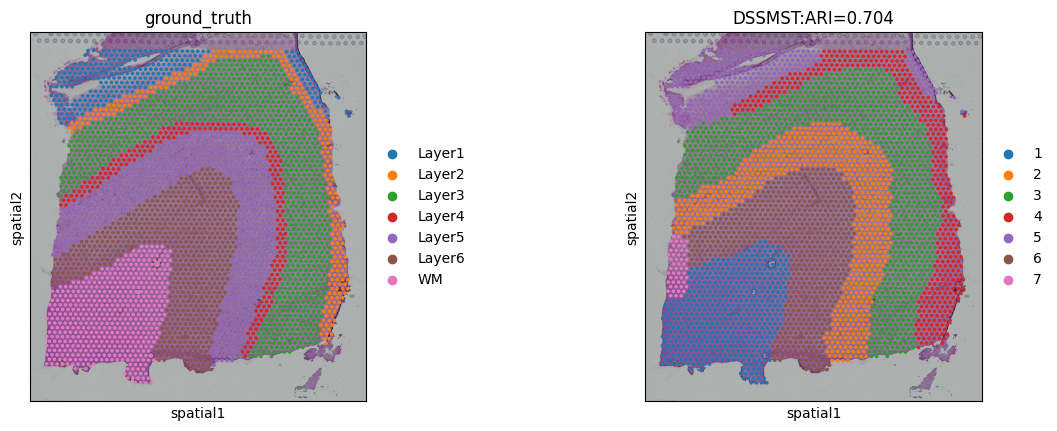

In [35]:
# plotting spatial clustering result 
sc.pl.spatial(adata,
              img_key="hires", 
              color=["ground_truth","domain"], 
              title=["ground_truth","DSSMST:ARI=%.3f"%ARI],
              show=True,)  